In [1]:
import pandas as pd
import missingno

enc = 'utf-8'

In [2]:
df_economics = pd.read_csv('../data/GR_EUROSTAT_Economics_Raw.csv', encoding=enc)
df_economics.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NAMA_10R_3GDP(1.0),Gross domestic product (GDP) at current market...,A,Annual,EUR_HAB,Euro per inhabitant,AL,Albania,2008,NaN,3000.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NAMA_10R_3GDP(1.0),Gross domestic product (GDP) at current market...,A,Annual,EUR_HAB,Euro per inhabitant,AL,Albania,2009,NaN,3000.0,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NAMA_10R_3GDP(1.0),Gross domestic product (GDP) at current market...,A,Annual,EUR_HAB,Euro per inhabitant,AL,Albania,2010,NaN,3100.0,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NAMA_10R_3GDP(1.0),Gross domestic product (GDP) at current market...,A,Annual,EUR_HAB,Euro per inhabitant,AL,Albania,2011,NaN,3200.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NAMA_10R_3GDP(1.0),Gross domestic product (GDP) at current market...,A,Annual,EUR_HAB,Euro per inhabitant,AL,Albania,2012,NaN,3300.0,NaN,NaN,NaN,NaN,NaN


In [3]:
df_economics.drop(columns=['STRUCTURE', 'STRUCTURE_NAME', 'Time frequency', 'Unit of measure', 'Geopolitical entity (reporting)', 'Time', 'Observation value', 'Observation status (Flag) V2 structure','CONF_STATUS','Confidentiality status (flag)'], inplace=True)
df_economics.rename(columns={'STRUCTURE_ID': 'DATAFLOW'}, inplace=True)
df_economics

,DATAFLOW,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,ESTAT:NAMA_10R_3GDP(1.0),A,EUR_HAB,AL,2008,3000.0,NaN
1,ESTAT:NAMA_10R_3GDP(1.0),A,EUR_HAB,AL,2009,3000.0,NaN
2,ESTAT:NAMA_10R_3GDP(1.0),A,EUR_HAB,AL,2010,3100.0,NaN
3,ESTAT:NAMA_10R_3GDP(1.0),A,EUR_HAB,AL,2011,3200.0,NaN
4,ESTAT:NAMA_10R_3GDP(1.0),A,EUR_HAB,AL,2012,3300.0,NaN
...,...,...,...,...,...,...,...
279558,ESTAT:NAMA_10R_3GDP(1.0),A,PPS_HAB_EU27_2020,TRC34,2019,30.0,NaN
279559,ESTAT:NAMA_10R_3GDP(1.0),A,PPS_HAB_EU27_2020,TRC34,2020,33.0,NaN
279560,ESTAT:NAMA_10R_3GDP(1.0),A,PPS_HAB_EU27_2020,TRC34,2021,28.0,NaN
279561,ESTAT:NAMA_10R_3GDP(1.0),A,PPS_HAB_EU27_2020,TRC34,2022,31.0,NaN


In [4]:
df_economics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279563 entries, 0 to 279562
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     279563 non-null  object 
 1   freq         279563 non-null  object 
 2   unit         279563 non-null  object 
 3   geo          279563 non-null  object 
 4   TIME_PERIOD  279563 non-null  int64  
 5   OBS_VALUE    279563 non-null  float64
 6   OBS_FLAG     51161 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 14.9+ MB


In [5]:
df_economics.freq.unique()

array(['A'], dtype=object)

In [6]:
df_economics.DATAFLOW.unique()

array(['ESTAT:NAMA_10R_3GDP(1.0)'], dtype=object)

In [7]:
df_economics.unit.unique()

array(['EUR_HAB', 'EUR_HAB_EU27_2020', 'MIO_EUR', 'MIO_NAC',
       'MIO_PPS_EU27_2020', 'PPS_EU27_2020_HAB', 'PPS_HAB_EU27_2020'],
      dtype=object)

In [8]:
df_economics.TIME_PERIOD.unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2022, 2023], dtype=int64)

In [9]:
nuts3 = df_economics.geo.unique()

In [10]:
df_economics_gr = df_economics.query("geo.str.match('EL\d{3}')").copy()

In [11]:
df_economics_gr = df_economics_gr[df_economics_gr.unit == 'MIO_EUR'].copy()

In [12]:
df_economics_gr.drop(columns=['DATAFLOW', 'freq', 'unit', 'OBS_FLAG'], inplace=True)

In [13]:
df_economics_gr.reset_index(drop=True, inplace=True)

In [14]:
df_economics_gr

,geo,TIME_PERIOD,OBS_VALUE
0,EL301,2000,9725.08
1,EL301,2001,10452.13
2,EL301,2002,11780.17
3,EL301,2003,12522.31
4,EL301,2004,13769.51
...,...,...,...
1191,EL653,2018,3207.99
1192,EL653,2019,3243.04
1193,EL653,2020,2907.59
1194,EL653,2021,3090.65


In [15]:
df_out = df_economics_gr.rename(columns={"geo": "NUTS3_CODE", "TIME_PERIOD": "YEAR", "OBS_VALUE": "MIO_EUR"}, errors="raise")

<Axes: >

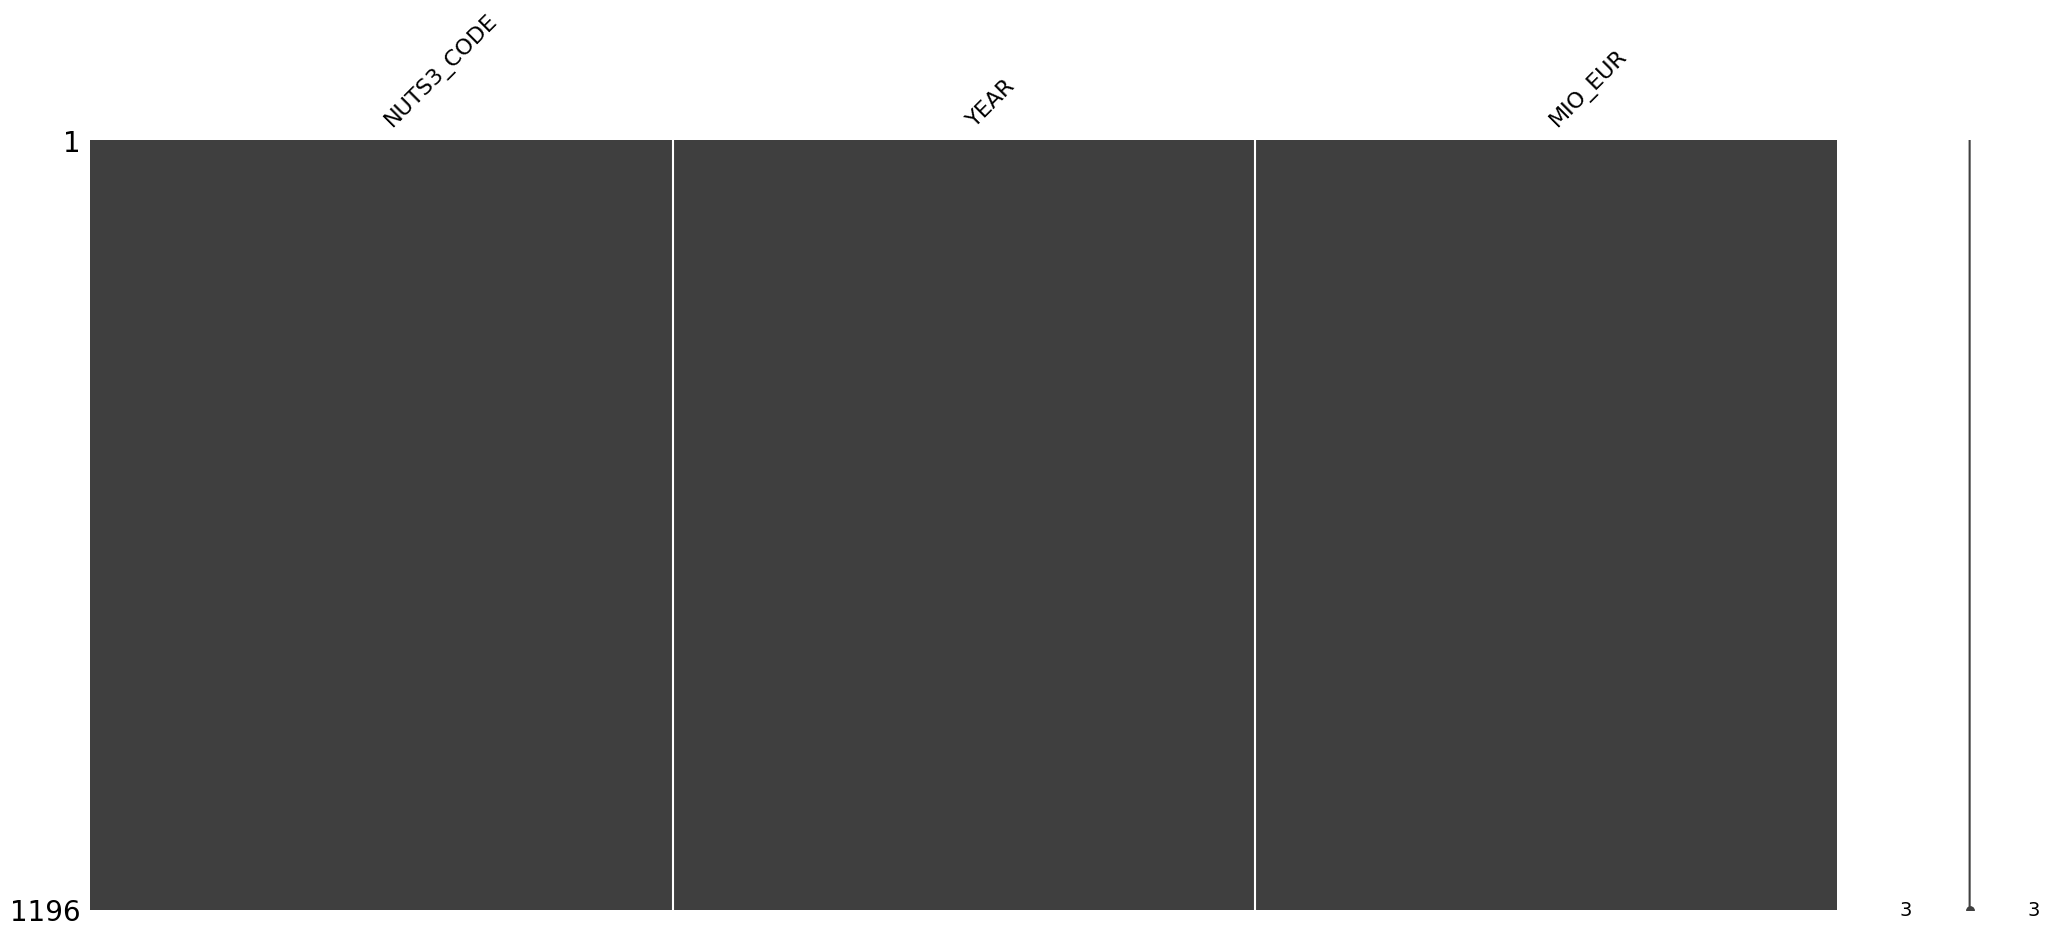

In [16]:
missingno.matrix(df_out)

In [17]:
df_out.to_csv('../data/GR_EUROSTAT_Economics_Processed.csv', index=False)